In [1]:
# Install pandas into the current Python environment (run this cell once), then import it
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas"])
import pandas as pd
subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "datasets"])
import matplotlib.pyplot as plt
from datasets import load_dataset
import sys, subprocess
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
from ast import literal_eval
df['job_skills']= df['job_skills'].apply(lambda x: literal_eval(x) if pd.notna(x) else x)


c:\Users\Admin\anaconda3\envs\python_data\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
import seaborn as sns

In [8]:
df_DA_US = df[(df['job_title_short']=='Data Analyst')&(df['job_country']=='United States')].copy()
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])
df_DA_US = df_DA_US.explode('job_skills')
df_DA_US_group = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median'])
df_DA_top_pay = df_DA_US_group.sort_values(by='median',ascending=False).head(10)
df_DA_skills = df_DA_US_group.sort_values(by='count',ascending=False).head(10).sort_values(by='median',ascending=False).head(10)

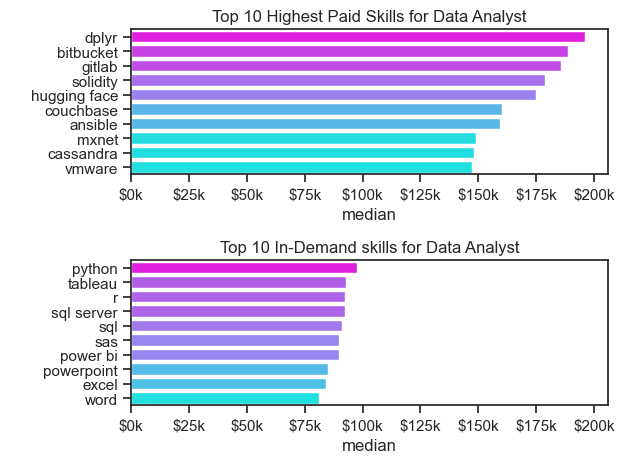

In [23]:
import matplotlib.ticker as mticker

sns.set_theme(style='ticks')
fig, ax = plt.subplots(2,1)

#Top 10 Highest Paid Skills for DA
sns.barplot(data=df_DA_top_pay, x='median',y=df_DA_top_pay.index,ax=ax[0],hue='median',palette='cool')
ax[0].legend().remove()
ax[0].set_ylabel(' ')
ax[0].set_title('Top 10 Highest Paid Skills for Data Analyst')

#df_DA_top_pay[::-1].plot(kind='barh',y = 'median', ax=ax[0],legend=False,ylabel=' ',title='Top 10 Highest Paid Skills for Data Analyst')
ax[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}k'))

#Top 10 in-demand skills for DA

sns.barplot(data=df_DA_skills, x='median',y=df_DA_skills.index,ax=ax[1],hue='median',palette='cool')
ax[1].legend().remove()
ax[1].set_ylabel(' ')
ax[1].set_title('Top 10 In-Demand skills for Data Analyst')

#df_DA_skills[::-1].plot(kind='barh', y='median',ax=ax[1],legend=False,ylabel = ' ',title='Top 10 In-Demand skills for Data Analyst')
ax[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}k'))
ax[1].set_xlim(ax[0].get_xlim())

plt.tight_layout()